In [1]:
print("Hello world")

Hello world


# Roulette Fraud Detection - Experimental Notebook

This notebook is the Phase 1 experimental workspace for roulette fraud detection.

## Immediate goals
- Connect to MongoDB and inspect the available collections
- Understand schema, data quality, and row coverage
- Build roulette-specific exploratory aggregates before modeling
- Identify candidate features for fraud types such as low-value bet spamming, multi-accounting, collusion, and bot-like play

## Scope for now
We are intentionally keeping this notebook focused on data understanding and feature discovery.
Production MLOps decisions, streaming design, graph pipelines, and model serving are deferred until we validate the data and establish a credible baseline.

## Collections assumed from the current plan
- `ccs`
- `game_names`
- `gk-users`
- `roulette_game_report`

## Security note
The connection string should be supplied through an environment variable named `MONGODB_URI` instead of being hardcoded into the notebook.

In [2]:
import json
import os
from pathlib import Path
from datetime import datetime, timedelta

import numpy as np
import pandas as pd
from pymongo import MongoClient
from pymongo.errors import PyMongoError
from bson import json_util
from dotenv import load_dotenv

import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", 200)
pd.set_option("display.max_rows", 200)
pd.set_option("display.width", 140)
sns.set_theme(style="whitegrid")

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / ".env").exists() and (PROJECT_ROOT.parent / ".env").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

load_dotenv(PROJECT_ROOT / ".env")

DATA_DIR = PROJECT_ROOT / "data_cache"
DATA_DIR.mkdir(parents=True, exist_ok=True)

DATABASE_NAME = os.getenv("MONGODB_DATABASE", "gk-reports")
COLLECTIONS = [
    os.getenv("MONGODB_COLLECTION_CCS", "ccs"),
    os.getenv("MONGODB_COLLECTION_GAME_NAMES", "game_names"),
    os.getenv("MONGODB_COLLECTION_USERS", "gk-users"),
    os.getenv("MONGODB_COLLECTION_ROULETTE_REPORT", "roulette_game_report"),
]

In [3]:
MONGODB_URI = os.getenv("MONGODB_URI")
if not MONGODB_URI:
    raise ValueError(
        "MONGODB_URI was not found. Add it to the workspace .env file before running this notebook."
    )


def get_client(uri: str) -> MongoClient:
    return MongoClient(uri, serverSelectionTimeoutMS=15000)


client = get_client(MONGODB_URI)
client.admin.command("ping")
db = client[DATABASE_NAME]

print("Connected successfully")
print("Database:", DATABASE_NAME)
print("Available target collections:", COLLECTIONS)


def collection_overview(database, collection_names: list[str]) -> pd.DataFrame:
    rows = []
    for name in collection_names:
        collection = database[name]
        try:
            sample_doc = collection.find_one()
            rows.append(
                {
                    "collection": name,
                    "estimated_count": collection.estimated_document_count(),
                    "sample_keys": sorted(sample_doc.keys()) if sample_doc else [],
                }
            )
        except PyMongoError as exc:
            rows.append(
                {
                    "collection": name,
                    "estimated_count": np.nan,
                    "sample_keys": [f"ERROR: {exc}"],
                }
            )
    return pd.DataFrame(rows)


overview_df = collection_overview(db, COLLECTIONS)
overview_df

Connected successfully
Database: gk-reports
Available target collections: ['ccs', 'game_names', 'gk-users', 'roulette_game_report']


,collection,estimated_count,sample_keys
0,ccs,41190,"[AM, __v, _id, business_report, ccs, confirmed..."
1,game_names,19,"[__v, _id, createdAt, game_name, label, update..."
2,gk-users,0,[]
3,roulette_game_report,33481580,"[__v, _id, bet_codes, bets, ccs_id, createdAt,..."


In [4]:
def normalize_records(records: list[dict]) -> pd.DataFrame:
    if not records:
        return pd.DataFrame()

    # Convert BSON-specific values such as ObjectId into JSON-safe primitives
    # before flattening so local parquet caching works reliably.
    safe_records = [json.loads(json_util.dumps(record)) for record in records]
    return pd.json_normalize(safe_records, sep=".")


def make_parquet_safe(frame: pd.DataFrame) -> pd.DataFrame:
    safe_frame = frame.copy()
    for column in safe_frame.columns:
        if safe_frame[column].dtype == "object":
            sample_values = safe_frame[column].dropna().head(20).tolist()
            if any(isinstance(value, (list, dict, tuple, set)) for value in sample_values):
                safe_frame[column] = safe_frame[column].apply(
                    lambda value: json.dumps(value, default=str) if isinstance(value, (list, dict, tuple, set)) else value
                )
            else:
                safe_frame[column] = safe_frame[column].apply(
                    lambda value: str(value) if value is not None and not isinstance(value, (str, int, float, bool)) else value
                )
    return safe_frame


def fetch_sample(
    collection_name: str,
    limit: int = 5000,
    query: dict | None = None,
    sort: list[tuple[str, int]] | None = None,
) -> pd.DataFrame:
    collection = db[collection_name]
    cursor = collection.find(query or {})
    if sort:
        cursor = cursor.sort(sort)
    records = list(cursor.limit(limit))
    frame = normalize_records(records)
    cache_path = DATA_DIR / f"{collection_name}_sample.parquet"
    if not frame.empty:
        make_parquet_safe(frame).to_parquet(cache_path, index=False)
    print(f"{collection_name}: fetched {len(frame):,} rows")
    return frame


samples = {name: fetch_sample(name, limit=3000) for name in COLLECTIONS}
{key: value.shape for key, value in samples.items()}

ccs: fetched 3,000 rows
game_names: fetched 19 rows
gk-users: fetched 0 rows
roulette_game_report: fetched 3,000 rows


{'ccs': (3000, 22),
 'game_names': (19, 6),
 'gk-users': (0, 0),
 'roulette_game_report': (3000, 27)}

In [5]:
def safe_nunique(series: pd.Series) -> int:
    normalized = series.dropna().apply(
        lambda value: json.dumps(value, sort_keys=True, default=str) if isinstance(value, (list, dict, tuple, set)) else value
    )
    return normalized.nunique(dropna=True)


def profile_frame(frame: pd.DataFrame, name: str) -> pd.DataFrame:
    if frame.empty:
        return pd.DataFrame({"collection": [name], "message": ["No rows returned"]})

    summary = pd.DataFrame(
        {
            "column": frame.columns,
            "dtype": frame.dtypes.astype(str).values,
            "missing_pct": frame.isna().mean().mul(100).round(2).values,
            "n_unique": [safe_nunique(frame[column]) for column in frame.columns],
        }
    )
    summary.insert(0, "collection", name)
    return summary.sort_values(["missing_pct", "n_unique"], ascending=[False, True])


profiles = {name: profile_frame(frame, name) for name, frame in samples.items()}
profiles[os.getenv("MONGODB_COLLECTION_ROULETTE_REPORT", "roulette_game_report")].head(50)

,collection,column,dtype,missing_pct,n_unique
18,roulette_game_report,output_stamp_id,float64,53.77,249
20,roulette_game_report,output_session_id,float64,53.77,610
17,roulette_game_report,output_credit,float64,53.77,1212
0,roulette_game_report,version,object,0.00,1
9,roulette_game_report,game,object,0.00,1
10,roulette_game_report,fever,int64,0.00,1
14,roulette_game_report,take,object,0.00,1
22,roulette_game_report,__v,int64,0.00,1
19,roulette_game_report,output_take,object,0.00,2
1,roulette_game_report,draw_id,int64,0.00,5


In [6]:
roulette_df = samples[os.getenv("MONGODB_COLLECTION_ROULETTE_REPORT", "roulette_game_report")].copy()
roulette_df.head()


def pick_first_column(columns: pd.Index, candidates: list[str]) -> str | None:
    column_list = list(columns)
    lowered = {column.lower(): column for column in column_list}

    for candidate in candidates:
        if candidate in lowered:
            return lowered[candidate]

    for candidate in candidates:
        for column in column_list:
            if candidate in column.lower():
                return column
    return None


player_col = pick_first_column(roulette_df.columns, ["member_id", "player", "user", "member", "ccs_id"])
timestamp_col = pick_first_column(roulette_df.columns, ["createdat.$date", "createdat", "time", "date", "placed"])
round_col = pick_first_column(roulette_df.columns, ["round", "spin", "game_id", "draw_id", "draw_number"])
outcome_col = pick_first_column(roulette_df.columns, ["win_points", "outcome", "result", "win", "status"])

roulette_schema_focus = pd.DataFrame(
    {
        "semantic_field": [
            "player_or_ccs",
            "timestamp",
            "round",
            "outcome",
            "bets_column_present",
            "bet_codes_column_present",
        ],
        "detected_column": [
            player_col,
            timestamp_col,
            round_col,
            outcome_col,
            "bets" if "bets" in roulette_df.columns else None,
            "bet_codes" if "bet_codes" in roulette_df.columns else None,
        ],
    }
)

roulette_schema_focus

,semantic_field,detected_column
0,player_or_ccs,member_id
1,timestamp,createdAt.$date
2,round,draw_id
3,outcome,win_points
4,bets_column_present,bets
5,bet_codes_column_present,bet_codes


In [7]:
working_df = roulette_df.copy()

if timestamp_col:
    working_df[timestamp_col] = pd.to_datetime(working_df[timestamp_col], errors="coerce", utc=True)

# Exploded bets are useful for allocation analysis within a draw, but not as independent transactions.
bets_exploded = pd.DataFrame()
if "bets" in roulette_df.columns:
    source_columns = list(
        dict.fromkeys(
            [
                col
                for col in [player_col, timestamp_col, round_col, "bets", "total_bet_amount", "win_points", "session_id", "ccs_id", "member_id"]
                if col in roulette_df.columns
            ]
        )
    )
    bets_series = roulette_df["bets"].dropna()
    bets_exploded = roulette_df.loc[bets_series.index, source_columns].explode("bets")
    bets_exploded = bets_exploded[bets_exploded["bets"].notna()].copy()
    if not bets_exploded.empty:
        bets_detail = pd.json_normalize(bets_exploded["bets"])
        bets_exploded = bets_exploded.drop(columns=["bets"]).reset_index(drop=True).join(bets_detail)
        if timestamp_col and timestamp_col in bets_exploded.columns:
            bets_exploded[timestamp_col] = pd.to_datetime(bets_exploded[timestamp_col], errors="coerce", utc=True)

bet_amount_col = pick_first_column(bets_exploded.columns if not bets_exploded.empty else roulette_df.columns, ["bet_amount", "amount", "stake", "wager", "sum", "total_bet_amount"])
bet_type_col = pick_first_column(bets_exploded.columns if not bets_exploded.empty else roulette_df.columns, ["bet_type", "code", "selection", "position", "slot", "number"])

if not bets_exploded.empty and bet_amount_col and bet_amount_col in bets_exploded.columns:
    bets_exploded[bet_amount_col] = pd.to_numeric(bets_exploded[bet_amount_col], errors="coerce")

if "bets" in working_df.columns:
    working_df["bets_per_draw"] = working_df["bets"].apply(lambda value: len(value) if isinstance(value, list) else 0)
    working_df["nonzero_bets_per_draw"] = working_df["bets"].apply(
        lambda values: sum(float(bet.get("bet_amount", 0) or 0) > 0 for bet in values) if isinstance(values, list) else 0
    )
    working_df["tiny_bet_ratio_in_draw"] = working_df["bets"].apply(
        lambda values: (
            sum(0 < float(bet.get("bet_amount", 0) or 0) <= 1 for bet in values) / len(values)
            if isinstance(values, list) and len(values) > 0
            else np.nan
        )
    )
    working_df["max_bet_amount_in_draw"] = working_df["bets"].apply(
        lambda values: max((float(bet.get("bet_amount", 0) or 0) for bet in values), default=0.0) if isinstance(values, list) else 0.0
    )
    working_df["bet_amount_std_in_draw"] = working_df["bets"].apply(
        lambda values: np.std([float(bet.get("bet_amount", 0) or 0) for bet in values]) if isinstance(values, list) and len(values) > 0 else np.nan
    )

if "total_bet_amount" in working_df.columns:
    working_df["total_bet_amount"] = pd.to_numeric(working_df["total_bet_amount"], errors="coerce")
if "win_points" in working_df.columns:
    working_df["win_points"] = pd.to_numeric(working_df["win_points"], errors="coerce")
if {"total_bet_amount", "win_points"}.issubset(working_df.columns):
    working_df["net_result_in_draw"] = working_df["win_points"] - working_df["total_bet_amount"]

base_behavior_agg = None
if player_col:
    base_agg_spec = {
        player_col: "count",
        "total_bet_amount": ["mean", "std", "sum"] if "total_bet_amount" in working_df.columns else "count",
        "win_points": ["mean", "std", "sum"] if "win_points" in working_df.columns else "count",
        "bets_per_draw": ["mean", "std"] if "bets_per_draw" in working_df.columns else "count",
        "nonzero_bets_per_draw": ["mean", "std"] if "nonzero_bets_per_draw" in working_df.columns else "count",
        "tiny_bet_ratio_in_draw": ["mean", "std"] if "tiny_bet_ratio_in_draw" in working_df.columns else "count",
    }
    base_agg_spec = {key: value for key, value in base_agg_spec.items() if key in working_df.columns}
    base_behavior_agg = working_df.groupby(player_col).agg(base_agg_spec)
    base_behavior_agg.columns = ["_".join(part for part in col if part) if isinstance(col, tuple) else col for col in base_behavior_agg.columns]
    if f"{player_col}_count" in base_behavior_agg.columns:
        base_behavior_agg = base_behavior_agg.rename(columns={f"{player_col}_count": "draw_record_count"})
    base_behavior_agg = base_behavior_agg.reset_index()

behavior_agg = base_behavior_agg.copy() if base_behavior_agg is not None else None

{
    "roulette_rows": len(roulette_df),
    "exploded_bet_rows": len(bets_exploded),
    "player_identifier": player_col,
    "timestamp_identifier": timestamp_col,
    "round_identifier": round_col,
    "bet_amount_identifier": bet_amount_col,
    "bet_type_identifier": bet_type_col,
    "sample_bet_columns": bets_exploded.columns.tolist()[:20] if not bets_exploded.empty else [],
}

{'roulette_rows': 3000,
 'exploded_bet_rows': 114000,
 'player_identifier': 'member_id',
 'timestamp_identifier': 'createdAt.$date',
 'round_identifier': 'draw_id',
 'bet_amount_identifier': 'bet_amount',
 'bet_type_identifier': 'number',
 'sample_bet_columns': ['member_id',
  'createdAt.$date',
  'draw_id',
  'total_bet_amount',
  'win_points',
  'session_id',
  'ccs_id',
  'number',
  'bet_amount',
  '_id.$oid']}

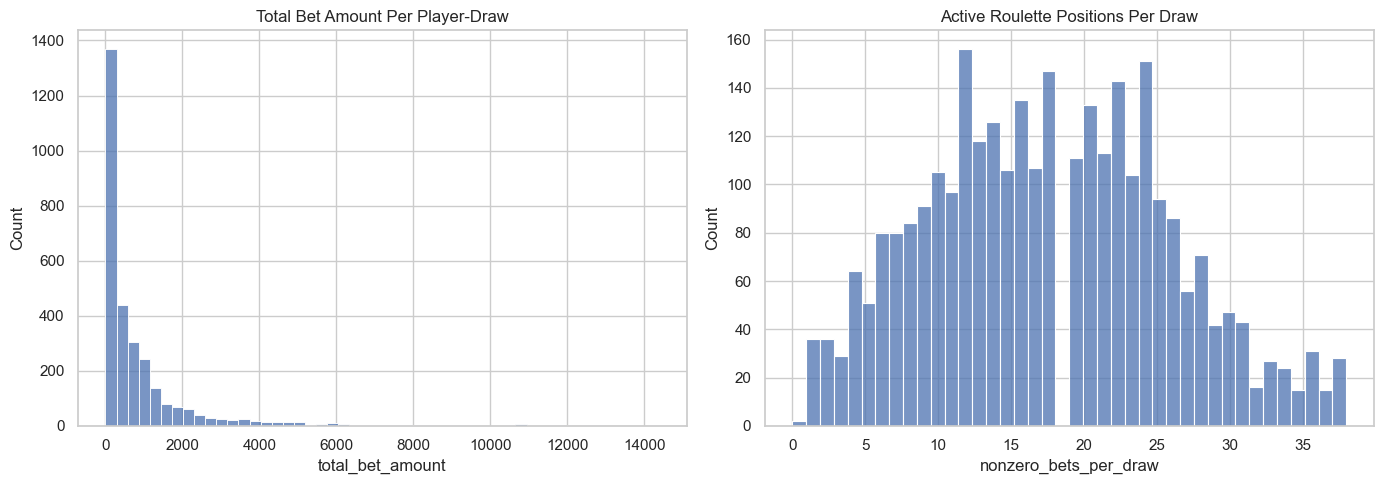

,member_id,draw_record_count,total_bet_amount_mean,total_bet_amount_std,total_bet_amount_sum,win_points_mean,win_points_std,win_points_sum,bets_per_draw_mean,bets_per_draw_std,nonzero_bets_per_draw_mean,nonzero_bets_per_draw_std,tiny_bet_ratio_in_draw_mean,tiny_bet_ratio_in_draw_std
0,GK00100378,5,3.000000,0.000000,15.0,3.6,4.929503,18.0,38.0,0.0,12.000000,0.000000,0.315789,0.000000
1,GK00100390,5,350.400000,106.811984,1752.0,79.2,177.096584,396.0,38.0,0.0,21.800000,2.489980,0.000000,0.000000
2,GK00100436,5,3.000000,0.000000,15.0,3.6,4.929503,18.0,38.0,0.0,12.000000,0.000000,0.315789,0.000000
3,GK00100447,1,1510.000000,NaN,1510.0,0.0,NaN,0.0,38.0,NaN,5.000000,NaN,0.000000,NaN
4,GK00100861,5,5.000000,0.000000,25.0,5.0,0.000000,25.0,38.0,0.0,36.000000,0.000000,0.947368,0.000000
5,GK00102129,2,338.500000,30.405592,677.0,360.0,25.455844,720.0,38.0,0.0,26.000000,0.000000,0.000000,0.000000
6,GK00102789,5,3384.000000,197.180121,16920.0,2268.0,2105.307578,11340.0,38.0,0.0,22.800000,1.095445,0.000000,0.000000
7,GK00102909,5,696.800000,193.413288,3484.0,1656.0,2807.076771,8280.0,38.0,0.0,14.200000,5.118594,0.000000,0.000000
8,GK00104194,5,664.000000,166.485735,3320.0,945.0,1121.394221,4725.0,38.0,0.0,13.800000,4.969909,0.000000,0.000000
9,GK00104927,5,192.400000,15.517732,962.0,72.0,63.320613,360.0,38.0,0.0,38.000000,0.000000,0.526316,0.000000


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

if "total_bet_amount" in working_df.columns and working_df["total_bet_amount"].notna().any():
    sns.histplot(working_df["total_bet_amount"].dropna(), bins=50, ax=axes[0])
    axes[0].set_title("Total Bet Amount Per Player-Draw")
else:
    axes[0].text(0.5, 0.5, "Total bet amount not detected", ha="center", va="center")
    axes[0].set_axis_off()

if "nonzero_bets_per_draw" in working_df.columns and working_df["nonzero_bets_per_draw"].notna().any():
    sns.histplot(working_df["nonzero_bets_per_draw"].dropna(), bins=40, ax=axes[1])
    axes[1].set_title("Active Roulette Positions Per Draw")
else:
    axes[1].text(0.5, 0.5, "Draw-level active position count unavailable", ha="center", va="center")
    axes[1].set_axis_off()

plt.tight_layout()
plt.show()

behavior_agg.head(20) if behavior_agg is not None else "No aggregate view available yet."

In [ ]:
ccs_df = samples[os.getenv("MONGODB_COLLECTION_CCS", "ccs")].copy()

# Diagnose resolved column names
print("ccs_df columns:", ccs_df.columns.tolist())

ccs_join_col = pick_first_column(ccs_df.columns, ["ccs", "ccs_id", "manager", "name", "_id.$oid", "id"])
ccs_name_col = pick_first_column(ccs_df.columns, ["ccs", "manager", "name", "confirmed"])

print(f"ccs_join_col resolved to: {ccs_join_col!r}")
print(f"ccs_name_col resolved to: {ccs_name_col!r}")

if ccs_join_col and ccs_join_col in ccs_df.columns:
    print("\nSample values of ccs_join_col:")
    print(ccs_df[ccs_join_col].dropna().head(10).tolist())

roulette_core_cols = [
    col
    for col in [player_col, "ccs_id", "session_id", round_col, timestamp_col, "total_bet_amount", "win_points"]
    if col and col in roulette_df.columns
]
roulette_core = roulette_df[roulette_core_cols].copy()
if timestamp_col and timestamp_col in roulette_core.columns:
    roulette_core[timestamp_col] = pd.to_datetime(roulette_core[timestamp_col], errors="coerce", utc=True)

ccs_player_summary = (
    roulette_core.groupby("ccs_id")
    .agg(
        unique_players=(player_col, "nunique"),
        unique_sessions=("session_id", "nunique"),
        unique_draws=(round_col, "nunique") if round_col else (player_col, "size"),
        roulette_rows=(player_col, "size"),
        total_record_bet_amount=("total_bet_amount", "sum"),
        total_win_points=("win_points", "sum"),
    )
    .reset_index()
)

# FIX: ccs_join_col and ccs_name_col both resolve to "ccs".
# rename({"ccs": "ccs_id", "ccs": "ccs_name"}) is a dict with duplicate keys;
# Python keeps only the last entry so "ccs_id" rename never happens.
# merge(on="ccs_id") then fails because ccs_lookup has no ccs_id column.
if ccs_join_col and ccs_name_col and ccs_join_col in ccs_df.columns:
    if ccs_join_col == ccs_name_col:
        ccs_lookup = (
            ccs_df[[ccs_join_col]]
            .drop_duplicates()
            .rename(columns={ccs_join_col: "ccs_id"})
        )
        ccs_lookup["ccs_name"] = ccs_lookup["ccs_id"]
    else:
        cols_to_select = list(dict.fromkeys([ccs_join_col, ccs_name_col]))
        ccs_lookup = (
            ccs_df[cols_to_select]
            .drop_duplicates()
            .rename(columns={ccs_join_col: "ccs_id", ccs_name_col: "ccs_name"})
        )
    ccs_player_summary = ccs_player_summary.merge(ccs_lookup, on="ccs_id", how="left")

ccs_player_summary = ccs_player_summary.sort_values("roulette_rows", ascending=False)

print("\nSample ccs_id values in roulette data (first 10 unique):")
print(roulette_core["ccs_id"].dropna().unique()[:10].tolist())

hierarchy_overview = {
    "sampled_ccs_count": roulette_core["ccs_id"].nunique() if "ccs_id" in roulette_core.columns else None,
    "sampled_player_count": roulette_core[player_col].nunique() if player_col else None,
    "avg_players_per_ccs": round(ccs_player_summary["unique_players"].mean(), 2) if not ccs_player_summary.empty else None,
    "median_players_per_ccs": round(ccs_player_summary["unique_players"].median(), 2) if not ccs_player_summary.empty else None,
    "avg_rows_per_player": round(roulette_core.groupby(player_col).size().mean(), 2) if player_col else None,
    "ccs_name_match_rate": round(ccs_player_summary["ccs_name"].notna().mean(), 4) if "ccs_name" in ccs_player_summary.columns else None,
}

hierarchy_overview, ccs_player_summary.head(15)


In [ ]:
time_pattern_df = roulette_core.copy()
if timestamp_col and timestamp_col in time_pattern_df.columns:
    time_pattern_df["event_date"] = time_pattern_df[timestamp_col].dt.date
    time_pattern_df["event_hour"] = time_pattern_df[timestamp_col].dt.hour

hourly_activity = (
    time_pattern_df.groupby("event_hour").size().rename("roulette_rows").reset_index()
    if "event_hour" in time_pattern_df.columns
    else pd.DataFrame()
)

daily_activity = (
    time_pattern_df.groupby("event_date").size().rename("roulette_rows").reset_index()
    if "event_date" in time_pattern_df.columns
    else pd.DataFrame()
)

player_behavior_summary = pd.DataFrame()
if player_col and player_col in working_df.columns:
    player_behavior_df = working_df.copy()
    if timestamp_col and timestamp_col in player_behavior_df.columns:
        player_behavior_df = player_behavior_df.sort_values([player_col, timestamp_col])
        player_behavior_df["inter_draw_seconds"] = player_behavior_df.groupby(player_col)[timestamp_col].diff().dt.total_seconds()

    player_behavior_summary = (
        player_behavior_df.groupby(player_col)
        .agg(
            draw_count=(round_col, "nunique") if round_col else (player_col, "size"),
            session_count=("session_id", "nunique") if "session_id" in player_behavior_df.columns else (player_col, "size"),
            avg_total_bet_amount=("total_bet_amount", "mean") if "total_bet_amount" in player_behavior_df.columns else (player_col, "size"),
            std_total_bet_amount=("total_bet_amount", "std") if "total_bet_amount" in player_behavior_df.columns else (player_col, "size"),
            avg_nonzero_bets_per_draw=("nonzero_bets_per_draw", "mean") if "nonzero_bets_per_draw" in player_behavior_df.columns else (player_col, "size"),
            avg_tiny_bet_ratio=("tiny_bet_ratio_in_draw", "mean") if "tiny_bet_ratio_in_draw" in player_behavior_df.columns else (player_col, "size"),
            avg_max_bet_amount_in_draw=("max_bet_amount_in_draw", "mean") if "max_bet_amount_in_draw" in player_behavior_df.columns else (player_col, "size"),
            avg_inter_draw_seconds=("inter_draw_seconds", "mean") if "inter_draw_seconds" in player_behavior_df.columns else (player_col, "size"),
            std_inter_draw_seconds=("inter_draw_seconds", "std") if "inter_draw_seconds" in player_behavior_df.columns else (player_col, "size"),
        )
        .reset_index()
    )
    low_bet_threshold = player_behavior_summary["avg_total_bet_amount"].quantile(0.10) if "avg_total_bet_amount" in player_behavior_summary.columns else np.nan
    if "avg_total_bet_amount" in player_behavior_summary.columns:
        player_behavior_summary["low_avg_bet_flag"] = player_behavior_summary["avg_total_bet_amount"] <= low_bet_threshold
    player_behavior_summary = player_behavior_summary.sort_values("draw_count", ascending=False)
else:
    low_bet_threshold = np.nan

player_behavior_summary.head(15), {"low_avg_bet_threshold": low_bet_threshold}

(      member_id  draw_count  session_count  avg_total_bet_amount  std_total_bet_amount  avg_nonzero_bets_per_draw  avg_tiny_bet_ratio  \
 819  GK00555301           5              1                 813.0            223.427841                       17.0            0.000000   
 0    GK00100378           5              1                   3.0              0.000000                       12.0            0.315789   
 1    GK00100390           5              1                 350.4            106.811984                       21.8            0.000000   
 2    GK00100436           5              1                   3.0              0.000000                       12.0            0.315789   
 802  GK00547994           5              1                  65.6             22.006817                       15.4            0.000000   
 799  GK00546487           5              1                 874.0             92.628289                       14.6            0.000000   
 796  GK00545606           5      

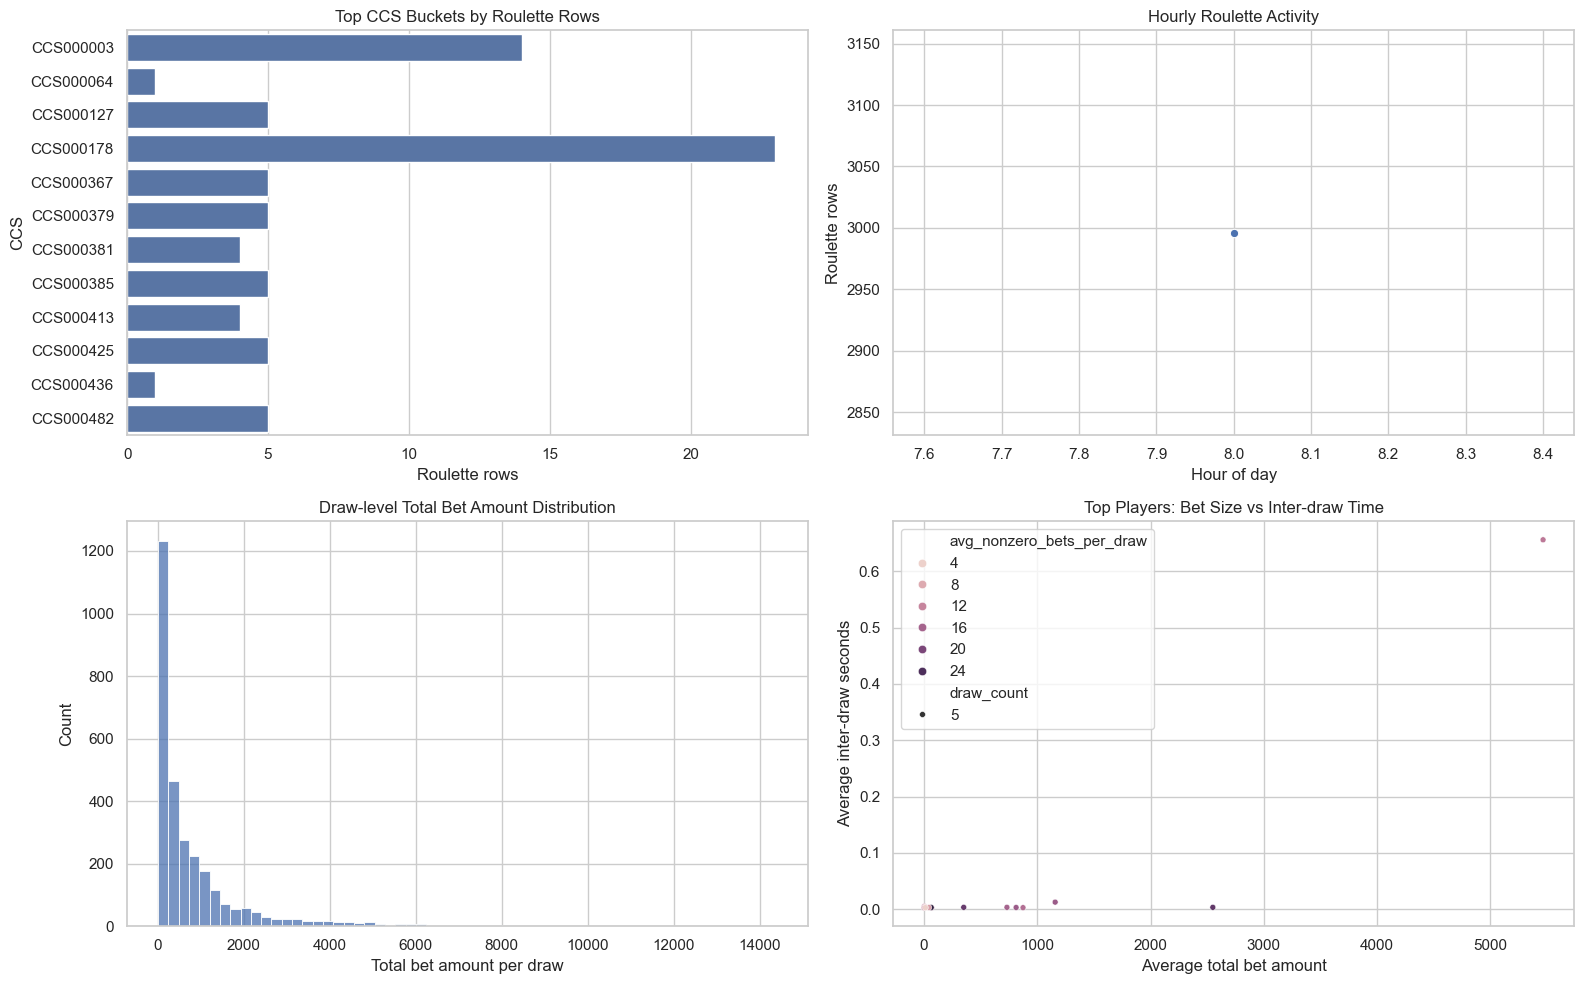

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

if not ccs_player_summary.empty:
    top_ccs = ccs_player_summary.head(12).copy()
    top_ccs_labels = top_ccs["ccs_name"] if "ccs_name" in top_ccs.columns else top_ccs["ccs_id"]
    sns.barplot(x=top_ccs["roulette_rows"], y=top_ccs_labels, ax=axes[0, 0])
    axes[0, 0].set_title("Top CCS Buckets by Roulette Rows")
    axes[0, 0].set_xlabel("Roulette rows")
    axes[0, 0].set_ylabel("CCS")
else:
    axes[0, 0].text(0.5, 0.5, "CCS summary unavailable", ha="center", va="center")
    axes[0, 0].set_axis_off()

if not hourly_activity.empty:
    sns.lineplot(data=hourly_activity, x="event_hour", y="roulette_rows", marker="o", ax=axes[0, 1])
    axes[0, 1].set_title("Hourly Roulette Activity")
    axes[0, 1].set_xlabel("Hour of day")
    axes[0, 1].set_ylabel("Roulette rows")
else:
    axes[0, 1].text(0.5, 0.5, "Timestamp activity unavailable", ha="center", va="center")
    axes[0, 1].set_axis_off()

if "total_bet_amount" in working_df.columns:
    sns.histplot(working_df["total_bet_amount"].dropna(), bins=60, ax=axes[1, 0])
    axes[1, 0].set_title("Draw-level Total Bet Amount Distribution")
    axes[1, 0].set_xlabel("Total bet amount per draw")
else:
    axes[1, 0].text(0.5, 0.5, "Bet amount unavailable", ha="center", va="center")
    axes[1, 0].set_axis_off()

if not player_behavior_summary.empty:
    top_players = player_behavior_summary.head(15)
    sns.scatterplot(
        data=top_players,
        x="avg_total_bet_amount",
        y="avg_inter_draw_seconds",
        size="draw_count",
        hue="avg_nonzero_bets_per_draw",
        ax=axes[1, 1],
    )
    axes[1, 1].set_title("Top Players: Bet Size vs Inter-draw Time")
    axes[1, 1].set_xlabel("Average total bet amount")
    axes[1, 1].set_ylabel("Average inter-draw seconds")
else:
    axes[1, 1].text(0.5, 0.5, "Player behavior summary unavailable", ha="center", va="center")
    axes[1, 1].set_axis_off()

plt.tight_layout()
plt.show()

In [ ]:
suspicious_velocity = pd.DataFrame()
if not player_behavior_summary.empty:
    suspicious_velocity = player_behavior_summary.copy()
    suspicious_velocity = suspicious_velocity[
        suspicious_velocity["avg_inter_draw_seconds"].notna()
        & suspicious_velocity["avg_total_bet_amount"].notna()
    ].copy()
    suspicious_velocity["speed_rank"] = suspicious_velocity["avg_inter_draw_seconds"].rank(method="min")
    suspicious_velocity["low_amount_rank"] = suspicious_velocity["avg_total_bet_amount"].rank(method="min")
    suspicious_velocity["tiny_ratio_rank"] = suspicious_velocity["avg_tiny_bet_ratio"].rank(method="min", ascending=False)
    suspicious_velocity["volume_rank"] = suspicious_velocity["draw_count"].rank(method="dense", ascending=False)
    suspicious_velocity["suspicion_score"] = (
        suspicious_velocity["volume_rank"]
        + suspicious_velocity["speed_rank"]
        + suspicious_velocity["low_amount_rank"]
        + suspicious_velocity["tiny_ratio_rank"]
    )
    suspicious_velocity = suspicious_velocity.sort_values("suspicion_score").head(20)

suspicious_velocity

,member_id,draw_count,session_count,avg_total_bet_amount,std_total_bet_amount,avg_nonzero_bets_per_draw,avg_tiny_bet_ratio,avg_max_bet_amount_in_draw,avg_inter_draw_seconds,std_inter_draw_seconds,low_avg_bet_flag,speed_rank,low_amount_rank,tiny_ratio_rank,volume_rank,suspicion_score
2,GK00100436,5,1,3.00,0.000000e+00,12.0,0.315789,0.250000,0.002500,0.000577,True,9.0,1.0,11.0,1.0,22.0
32,GK00118513,4,1,3.00,0.000000e+00,12.0,0.315789,0.250000,0.002333,0.000577,True,8.0,1.0,11.0,2.0,22.0
28,GK00117233,5,1,3.00,0.000000e+00,12.0,0.315789,0.250000,0.002500,0.000577,True,9.0,1.0,11.0,1.0,22.0
484,GK00281630,2,1,13.50,6.363961e+00,9.0,0.171053,2.375000,0.002000,NaN,True,1.0,22.0,29.0,4.0,56.0
213,GK00228462,2,1,26.00,2.828427e+01,12.0,0.144737,6.500000,0.002000,NaN,True,1.0,30.0,33.0,4.0,68.0
4,GK00100861,5,1,5.00,0.000000e+00,36.0,0.947368,0.138889,0.002750,0.000500,True,71.0,10.0,2.0,1.0,84.0
202,GK00227066,5,1,6.00,0.000000e+00,36.0,0.947368,0.166667,0.002750,0.000500,True,71.0,13.0,2.0,1.0,87.0
682,GK00515216,5,1,7.20,2.280351e+00,29.2,0.715789,2.150000,0.002750,0.000500,True,71.0,15.0,6.0,1.0,93.0
657,GK00509149,5,1,8.00,6.708204e+00,19.2,0.505263,0.388889,0.002750,0.000500,True,71.0,16.0,8.0,1.0,96.0
448,GK00276151,5,1,14.20,9.364828e+00,19.0,0.421053,1.983333,0.002750,0.000500,True,71.0,23.0,10.0,1.0,105.0


In [ ]:
record_bet_count_summary = pd.DataFrame()
if "bets" in roulette_df.columns:
    record_bet_count_summary = roulette_df[[player_col, "ccs_id", round_col, "bets"]].copy()
    record_bet_count_summary["bets_per_record"] = record_bet_count_summary["bets"].apply(lambda value: len(value) if isinstance(value, list) else 0)

draw_summary = pd.DataFrame()
if round_col and round_col in roulette_df.columns:
    draw_summary = (
        roulette_df.groupby(round_col)
        .agg(
            unique_players=(player_col, "nunique"),
            unique_ccs=("ccs_id", "nunique") if "ccs_id" in roulette_df.columns else (player_col, "nunique"),
            roulette_rows=(player_col, "size"),
            total_record_bet_amount=("total_bet_amount", "sum"),
            total_win_points=("win_points", "sum"),
        )
        .reset_index()
        .sort_values("roulette_rows", ascending=False)
    )

number_distribution = pd.DataFrame()
if not bets_exploded.empty and bet_type_col and bet_type_col in bets_exploded.columns:
    number_distribution = (
        bets_exploded.groupby(bet_type_col)
        .agg(
            bet_rows=(bet_amount_col, "size"),
            total_bet_amount=(bet_amount_col, "sum"),
            unique_players=(player_col, "nunique"),
        )
        .reset_index()
        .sort_values("bet_rows", ascending=False)
    )

roulette_mechanics_summary = {
    "avg_nested_bets_per_record": round(record_bet_count_summary["bets_per_record"].mean(), 2) if not record_bet_count_summary.empty else None,
    "median_nested_bets_per_record": round(record_bet_count_summary["bets_per_record"].median(), 2) if not record_bet_count_summary.empty else None,
    "min_number_observed": bets_exploded[bet_type_col].min() if not number_distribution.empty else None,
    "max_number_observed": bets_exploded[bet_type_col].max() if not number_distribution.empty else None,
    "sample_draw_count": roulette_df[round_col].nunique() if round_col else None,
}

roulette_mechanics_summary, number_distribution.head(15), draw_summary.head(10)

({'avg_nested_bets_per_record': np.float64(38.0),
  'median_nested_bets_per_record': np.float64(38.0),
  'min_number_observed': '0',
  'max_number_observed': '9',
  'sample_draw_count': 5},
    number  bet_rows  total_bet_amount  unique_players
 0       0      3000      36474.666667             822
 1      00      3000      36654.833333             822
 2       1      3000      71221.000000             822
 3      10      3000      55982.694444             822
 4      11      3000      81176.666667             822
 5      12      3000      84726.444444             822
 6      13      3000      91181.250000             822
 7      14      3000      69140.861111             822
 8      15      3000      86641.416667             822
 9      16      3000      83596.611111             822
 10     17      3000      85663.750000             822
 11     18      3000      84365.777778             822
 12     19      3000      48806.472222             822
 13      2      3000      65434.277778  

## Confirmed interpretation of the roulette data

Based on the clarified domain structure and the sampled data analyzed so far:

- `ccs_id` is the CCS manager bucket.
- `member_id` is the GK player identifier under a CCS.
- Each row in `roulette_game_report` represents one player's activity for one roulette draw.
- `draw_id` is the roulette round identifier.
- `session_id` is the session identifier.
- `total_bet_amount` is the record-level total wager for that player and draw.
- `win_points` is the record-level outcome or payout measure for that player and draw.
- The nested `bets` array contains the individual bet allocations for that player within that draw.
- Each element inside `bets` contains:
  - `number`: roulette position label
  - `bet_amount`: amount allocated to that position
- The system may support around 159 internal bet types, but the notebook-visible `bets` array is already aggregated into around 38 roulette positions.
- Very small decimal `bet_amount` values can be valid and are expected because of the aggregation logic.

Modeling implication:
- The natural transaction grain is draw-level per player.
- Behavioral fraud analysis should still be done across many draw-level rows per player, per session, and per CCS.
- The next EDA and feature engineering steps should be built around this separation.

In [ ]:
draw_level_feature_df = roulette_df.copy()

if timestamp_col and timestamp_col in draw_level_feature_df.columns:
    draw_level_feature_df[timestamp_col] = pd.to_datetime(draw_level_feature_df[timestamp_col], errors="coerce", utc=True)

if "bets" in draw_level_feature_df.columns:
    draw_level_feature_df["bets_per_draw"] = draw_level_feature_df["bets"].apply(lambda value: len(value) if isinstance(value, list) else 0)
    draw_level_feature_df["nonzero_bets_per_draw"] = draw_level_feature_df["bets"].apply(
        lambda values: sum(float(bet.get("bet_amount", 0) or 0) > 0 for bet in values) if isinstance(values, list) else 0
    )
    draw_level_feature_df["tiny_bets_per_draw"] = draw_level_feature_df["bets"].apply(
        lambda values: sum(0 < float(bet.get("bet_amount", 0) or 0) <= 1 for bet in values) if isinstance(values, list) else 0
    )
    draw_level_feature_df["max_bet_amount_in_draw"] = draw_level_feature_df["bets"].apply(
        lambda values: max((float(bet.get("bet_amount", 0) or 0) for bet in values), default=0.0) if isinstance(values, list) else 0.0
    )
    draw_level_feature_df["bet_amount_std_in_draw"] = draw_level_feature_df["bets"].apply(
        lambda values: np.std([float(bet.get("bet_amount", 0) or 0) for bet in values]) if isinstance(values, list) and len(values) > 0 else np.nan
    )
    draw_level_feature_df["bet_amount_mean_in_draw"] = draw_level_feature_df["bets"].apply(
        lambda values: np.mean([float(bet.get("bet_amount", 0) or 0) for bet in values]) if isinstance(values, list) and len(values) > 0 else np.nan
    )
    draw_level_feature_df["max_bet_share_in_draw"] = np.where(
        draw_level_feature_df["total_bet_amount"].fillna(0) > 0,
        draw_level_feature_df["max_bet_amount_in_draw"] / draw_level_feature_df["total_bet_amount"],
        np.nan,
    )
    draw_level_feature_df["tiny_bet_ratio_in_draw"] = np.where(
        draw_level_feature_df["bets_per_draw"] > 0,
        draw_level_feature_df["tiny_bets_per_draw"] / draw_level_feature_df["bets_per_draw"],
        np.nan,
    )

if "total_bet_amount" in draw_level_feature_df.columns and "win_points" in draw_level_feature_df.columns:
    draw_level_feature_df["net_result_in_draw"] = draw_level_feature_df["win_points"] - draw_level_feature_df["total_bet_amount"]

selected_draw_columns = [
    col
    for col in [
        player_col,
        "ccs_id",
        "session_id",
        round_col,
        timestamp_col,
        "total_bet_amount",
        "win_points",
        "net_result_in_draw",
        "bets_per_draw",
        "nonzero_bets_per_draw",
        "tiny_bet_ratio_in_draw",
        "max_bet_share_in_draw",
        "bet_amount_mean_in_draw",
        "bet_amount_std_in_draw",
    ]
    if col in draw_level_feature_df.columns
]

draw_level_feature_df[selected_draw_columns].head(20)

,member_id,ccs_id,session_id,draw_id,createdAt.$date,total_bet_amount,win_points,net_result_in_draw,bets_per_draw,nonzero_bets_per_draw,tiny_bet_ratio_in_draw,max_bet_share_in_draw,bet_amount_mean_in_draw,bet_amount_std_in_draw
0,GK00532849,CCS000003,547818481,7128154,2026-01-05 08:53:24.156000+00:00,6000.0,0.0,-6000.0,38,6,0.0,0.250000,157.894737,415.256154
1,GK00208484,CCS000003,547633548,7128154,2026-01-05 08:53:24.162000+00:00,9500.0,16200.0,6700.0,38,20,0.0,0.078947,250.000000,261.322547
2,GK00283011,CCS000003,547825275,7128154,2026-01-05 08:53:24.170000+00:00,6550.0,6300.0,-250.0,38,24,0.0,0.110687,172.368421,165.810358
3,GK00233021,CCS000003,547779145,7128154,2026-01-05 08:53:24.175000+00:00,5150.0,4500.0,-650.0,38,26,0.0,0.077670,135.526316,114.798390
4,GK00532849,CCS000003,547818481,7128155,2026-01-05 08:53:24.180000+00:00,3500.0,0.0,-3500.0,38,3,0.0,0.428571,92.105263,341.345310
5,GK00283011,CCS000003,547825275,7128155,2026-01-05 08:53:24.184000+00:00,8050.0,10800.0,2750.0,38,29,0.0,0.090062,211.842105,159.433293
6,GK00211091,CCS000003,547821996,7128155,2026-01-05 08:53:24.189000+00:00,158.0,0.0,-158.0,38,6,0.0,0.253165,4.157895,10.087841
7,GK00233021,CCS000003,547779145,7128155,2026-01-05 08:53:24.194000+00:00,5100.0,9000.0,3900.0,38,22,0.0,0.068627,134.210526,127.529802
8,GK00532849,CCS000003,547818481,7128156,2026-01-05 08:53:24.198000+00:00,6000.0,18000.0,12000.0,38,8,0.0,0.291667,157.894737,386.537653
9,GK00233021,CCS000003,547779145,7128156,2026-01-05 08:53:24.202000+00:00,5050.0,3600.0,-1450.0,38,25,0.0,0.069307,132.894737,108.104471


In [ ]:
player_history_df = pd.DataFrame()
if player_col and player_col in draw_level_feature_df.columns:
    player_history_df = draw_level_feature_df.copy()
    if timestamp_col and timestamp_col in player_history_df.columns:
        player_history_df = player_history_df.sort_values([player_col, timestamp_col])
        player_history_df["inter_draw_seconds"] = player_history_df.groupby(player_col)[timestamp_col].diff().dt.total_seconds()

    player_history_summary = (
        player_history_df.groupby(player_col)
        .agg(
            draws_played=(round_col, "nunique") if round_col else (player_col, "size"),
            sessions_played=("session_id", "nunique") if "session_id" in player_history_df.columns else (player_col, "size"),
            ccs_seen=("ccs_id", "nunique") if "ccs_id" in player_history_df.columns else (player_col, "size"),
            avg_total_bet_amount=("total_bet_amount", "mean") if "total_bet_amount" in player_history_df.columns else (player_col, "size"),
            std_total_bet_amount=("total_bet_amount", "std") if "total_bet_amount" in player_history_df.columns else (player_col, "size"),
            avg_net_result=("net_result_in_draw", "mean") if "net_result_in_draw" in player_history_df.columns else (player_col, "size"),
            std_net_result=("net_result_in_draw", "std") if "net_result_in_draw" in player_history_df.columns else (player_col, "size"),
            avg_nonzero_bets=("nonzero_bets_per_draw", "mean") if "nonzero_bets_per_draw" in player_history_df.columns else (player_col, "size"),
            avg_tiny_bet_ratio=("tiny_bet_ratio_in_draw", "mean") if "tiny_bet_ratio_in_draw" in player_history_df.columns else (player_col, "size"),
            avg_max_bet_share=("max_bet_share_in_draw", "mean") if "max_bet_share_in_draw" in player_history_df.columns else (player_col, "size"),
            avg_inter_draw_seconds=("inter_draw_seconds", "mean") if "inter_draw_seconds" in player_history_df.columns else (player_col, "size"),
            std_inter_draw_seconds=("inter_draw_seconds", "std") if "inter_draw_seconds" in player_history_df.columns else (player_col, "size"),
        )
        .reset_index()
        .sort_values("draws_played", ascending=False)
    )
else:
    player_history_summary = pd.DataFrame()

player_history_summary.head(20)

,member_id,draws_played,sessions_played,ccs_seen,avg_total_bet_amount,std_total_bet_amount,avg_net_result,std_net_result,avg_nonzero_bets,avg_tiny_bet_ratio,avg_max_bet_share,avg_inter_draw_seconds,std_inter_draw_seconds
819,GK00555301,5,1,1,813.0,223.427841,-201.0,921.672393,17.0,0.000000,0.116544,0.00300,0.000816
0,GK00100378,5,1,1,3.0,0.000000,0.6,4.929503,12.0,0.315789,0.083333,0.00500,0.003367
1,GK00100390,5,1,1,350.4,106.811984,-271.2,275.889833,21.8,0.000000,0.108378,0.00325,0.000500
2,GK00100436,5,1,1,3.0,0.000000,0.6,4.929503,12.0,0.315789,0.083333,0.00250,0.000577
802,GK00547994,5,1,1,65.6,22.006817,-36.8,69.416857,15.4,0.000000,0.104526,0.00250,0.000577
799,GK00546487,5,1,1,874.0,92.628289,8.0,966.835043,14.6,0.000000,0.193020,0.00275,0.000500
796,GK00545606,5,1,1,63.2,13.971399,-18.2,64.669931,27.0,0.178947,0.088774,0.00300,0.000000
795,GK00545368,5,1,1,42.6,27.208455,15.0,87.518569,9.0,0.000000,0.206866,0.00300,0.000000
793,GK00545016,5,1,1,2550.0,1060.070752,390.0,4470.095077,22.4,0.000000,0.147417,0.00325,0.000500
792,GK00544999,5,1,1,1158.0,373.991979,498.0,2141.464452,17.0,0.000000,0.134488,0.01250,0.005447


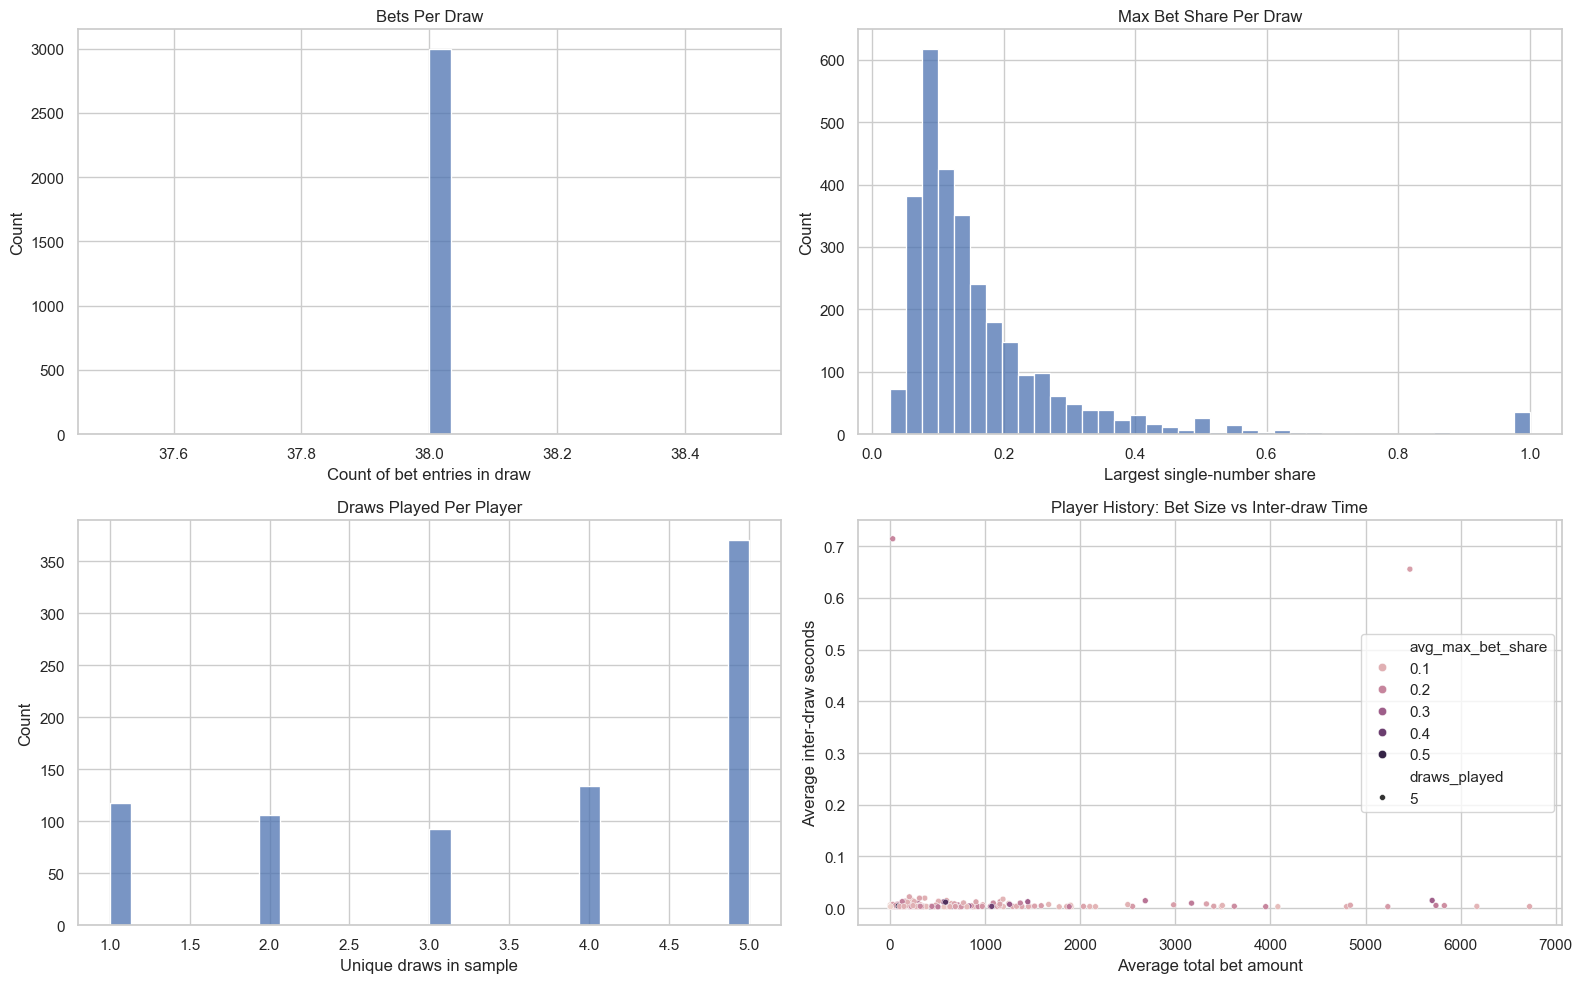

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

if "bets_per_draw" in draw_level_feature_df.columns:
    sns.histplot(draw_level_feature_df["bets_per_draw"].dropna(), bins=30, ax=axes[0, 0])
    axes[0, 0].set_title("Bets Per Draw")
    axes[0, 0].set_xlabel("Count of bet entries in draw")
else:
    axes[0, 0].text(0.5, 0.5, "Draw-level bet count unavailable", ha="center", va="center")
    axes[0, 0].set_axis_off()

if "max_bet_share_in_draw" in draw_level_feature_df.columns:
    sns.histplot(draw_level_feature_df["max_bet_share_in_draw"].dropna(), bins=40, ax=axes[0, 1])
    axes[0, 1].set_title("Max Bet Share Per Draw")
    axes[0, 1].set_xlabel("Largest single-number share")
else:
    axes[0, 1].text(0.5, 0.5, "Bet concentration unavailable", ha="center", va="center")
    axes[0, 1].set_axis_off()

if not player_history_summary.empty:
    sns.histplot(player_history_summary["draws_played"].dropna(), bins=30, ax=axes[1, 0])
    axes[1, 0].set_title("Draws Played Per Player")
    axes[1, 0].set_xlabel("Unique draws in sample")
else:
    axes[1, 0].text(0.5, 0.5, "Player history unavailable", ha="center", va="center")
    axes[1, 0].set_axis_off()

if not player_history_summary.empty:
    sns.scatterplot(
        data=player_history_summary.head(200),
        x="avg_total_bet_amount",
        y="avg_inter_draw_seconds",
        size="draws_played",
        hue="avg_max_bet_share",
        ax=axes[1, 1],
    )
    axes[1, 1].set_title("Player History: Bet Size vs Inter-draw Time")
    axes[1, 1].set_xlabel("Average total bet amount")
    axes[1, 1].set_ylabel("Average inter-draw seconds")
else:
    axes[1, 1].text(0.5, 0.5, "Player timing summary unavailable", ha="center", va="center")
    axes[1, 1].set_axis_off()

plt.tight_layout()
plt.show()

In [ ]:
draw_level_risk_candidates = pd.DataFrame()
if not player_history_summary.empty:
    draw_level_risk_candidates = player_history_summary.copy()
    risk_columns = [
        "avg_total_bet_amount",
        "avg_inter_draw_seconds",
        "avg_tiny_bet_ratio",
        "avg_max_bet_share",
        "draws_played",
    ]
    draw_level_risk_candidates = draw_level_risk_candidates.dropna(subset=[col for col in risk_columns if col in draw_level_risk_candidates.columns]).copy()
    draw_level_risk_candidates["fast_cycle_rank"] = draw_level_risk_candidates["avg_inter_draw_seconds"].rank(method="min")
    draw_level_risk_candidates["low_amount_rank"] = draw_level_risk_candidates["avg_total_bet_amount"].rank(method="min")
    draw_level_risk_candidates["tiny_ratio_rank"] = draw_level_risk_candidates["avg_tiny_bet_ratio"].rank(method="min", ascending=False)
    draw_level_risk_candidates["volume_rank"] = draw_level_risk_candidates["draws_played"].rank(method="dense", ascending=False)
    draw_level_risk_candidates["risk_score"] = (
        draw_level_risk_candidates["fast_cycle_rank"]
        + draw_level_risk_candidates["low_amount_rank"]
        + draw_level_risk_candidates["tiny_ratio_rank"]
        + draw_level_risk_candidates["volume_rank"]
    )
    draw_level_risk_candidates = draw_level_risk_candidates.sort_values("risk_score").head(25)

draw_level_risk_candidates

,member_id,draws_played,sessions_played,ccs_seen,avg_total_bet_amount,std_total_bet_amount,avg_net_result,std_net_result,avg_nonzero_bets,avg_tiny_bet_ratio,avg_max_bet_share,avg_inter_draw_seconds,std_inter_draw_seconds,fast_cycle_rank,low_amount_rank,tiny_ratio_rank,volume_rank,risk_score
2,GK00100436,5,1,1,3.000000,0.000000e+00,6.000000e-01,4.929503,12.000000,0.315789,0.083333,0.002500,0.000577,9.0,1.0,11.0,1.0,22.0
32,GK00118513,4,1,1,3.000000,0.000000e+00,-7.500000e-01,4.500000,12.000000,0.315789,0.083333,0.002333,0.000577,8.0,1.0,11.0,2.0,22.0
28,GK00117233,5,1,1,3.000000,0.000000e+00,6.000000e-01,4.929503,12.000000,0.315789,0.083333,0.002500,0.000577,9.0,1.0,11.0,1.0,22.0
484,GK00281630,2,1,1,13.500000,6.363961e+00,0.000000e+00,25.455844,9.000000,0.171053,0.152778,0.002000,NaN,1.0,22.0,29.0,4.0,56.0
213,GK00228462,2,1,1,26.000000,2.828427e+01,-2.600000e+01,28.284271,12.000000,0.144737,0.286232,0.002000,NaN,1.0,30.0,33.0,4.0,68.0
4,GK00100861,5,1,1,5.000000,0.000000e+00,-1.776357e-15,0.000000,36.000000,0.947368,0.027778,0.002750,0.000500,71.0,10.0,2.0,1.0,84.0
202,GK00227066,5,1,1,6.000000,0.000000e+00,-1.776357e-15,0.000000,36.000000,0.947368,0.027778,0.002750,0.000500,71.0,13.0,2.0,1.0,87.0
682,GK00515216,5,1,1,7.200000,2.280351e+00,3.000000e+00,17.691806,29.200000,0.715789,0.271296,0.002750,0.000500,71.0,15.0,6.0,1.0,93.0
657,GK00509149,5,1,1,8.000000,6.708204e+00,4.000000e+00,5.477226,19.200000,0.505263,0.052778,0.002750,0.000500,71.0,16.0,8.0,1.0,96.0
448,GK00276151,5,1,1,14.200000,9.364828e+00,-1.060000e+01,13.126309,19.000000,0.421053,0.132725,0.002750,0.000500,71.0,23.0,10.0,1.0,105.0


## Correlation and diagnostic plots

These plots are meant to answer practical questions:

- Which draw-level features move together?
- Which player-history features are redundant or strongly related?
- Are there visible regimes such as concentrated betting, low-value play, or unusually fast cycling?
- Which plots are descriptive now, and which will become evaluation plots once fraud labels arrive?

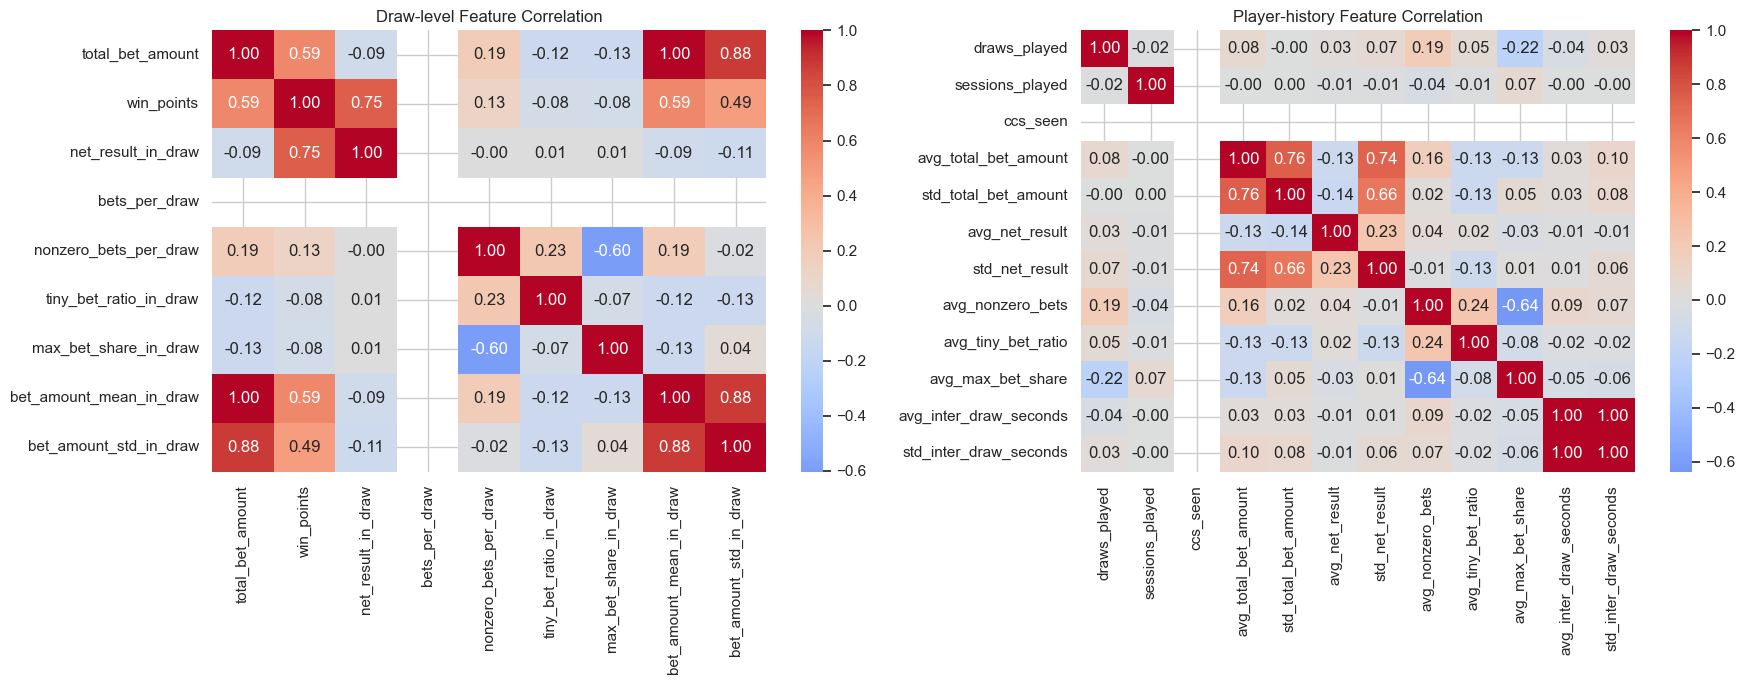

In [ ]:
draw_numeric_cols = [
    col
    for col in [
        "total_bet_amount",
        "win_points",
        "net_result_in_draw",
        "bets_per_draw",
        "nonzero_bets_per_draw",
        "tiny_bet_ratio_in_draw",
        "max_bet_share_in_draw",
        "bet_amount_mean_in_draw",
        "bet_amount_std_in_draw",
    ]
    if col in draw_level_feature_df.columns
]

player_numeric_cols = [
    col
    for col in [
        "draws_played",
        "sessions_played",
        "ccs_seen",
        "avg_total_bet_amount",
        "std_total_bet_amount",
        "avg_net_result",
        "std_net_result",
        "avg_nonzero_bets",
        "avg_tiny_bet_ratio",
        "avg_max_bet_share",
        "avg_inter_draw_seconds",
        "std_inter_draw_seconds",
    ]
    if col in player_history_summary.columns
]

draw_corr = draw_level_feature_df[draw_numeric_cols].corr() if draw_numeric_cols else pd.DataFrame()
player_corr = player_history_summary[player_numeric_cols].corr() if player_numeric_cols else pd.DataFrame()

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

if not draw_corr.empty:
    sns.heatmap(draw_corr, cmap="coolwarm", center=0, annot=True, fmt=".2f", ax=axes[0])
    axes[0].set_title("Draw-level Feature Correlation")
else:
    axes[0].text(0.5, 0.5, "No draw-level numeric features available", ha="center", va="center")
    axes[0].set_axis_off()

if not player_corr.empty:
    sns.heatmap(player_corr, cmap="coolwarm", center=0, annot=True, fmt=".2f", ax=axes[1])
    axes[1].set_title("Player-history Feature Correlation")
else:
    axes[1].text(0.5, 0.5, "No player-history numeric features available", ha="center", va="center")
    axes[1].set_axis_off()

plt.tight_layout()
plt.show()

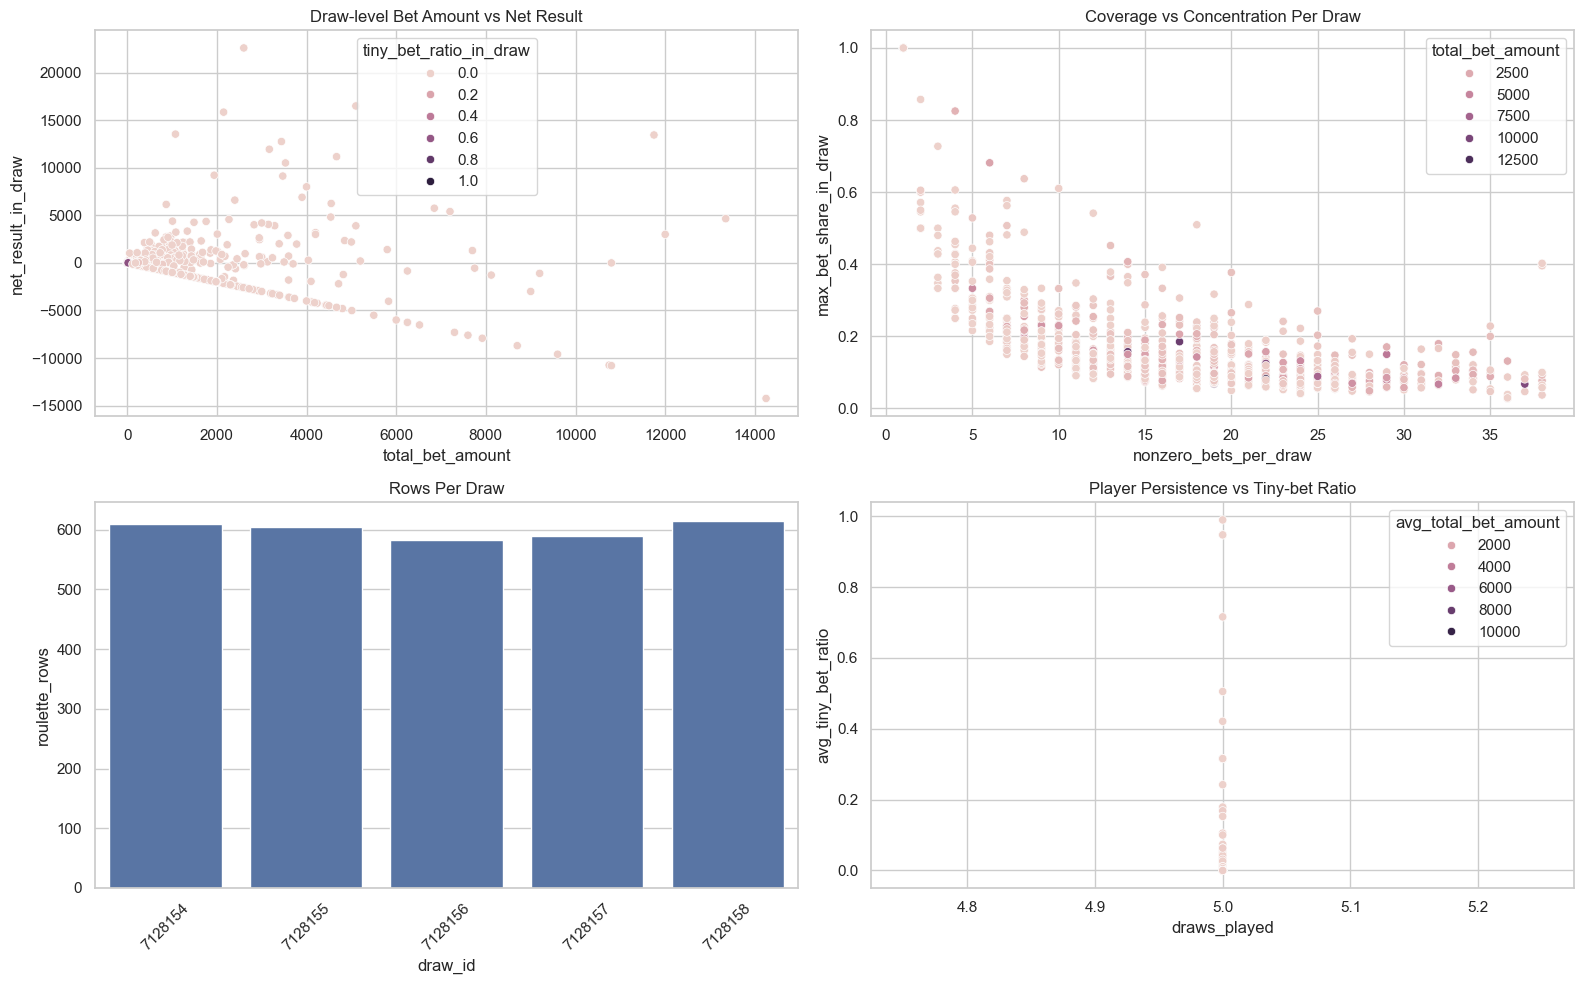

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

if {"total_bet_amount", "net_result_in_draw"}.issubset(draw_level_feature_df.columns):
    sns.scatterplot(
        data=draw_level_feature_df.sample(min(len(draw_level_feature_df), 1000), random_state=42),
        x="total_bet_amount",
        y="net_result_in_draw",
        hue="tiny_bet_ratio_in_draw" if "tiny_bet_ratio_in_draw" in draw_level_feature_df.columns else None,
        ax=axes[0, 0],
    )
    axes[0, 0].set_title("Draw-level Bet Amount vs Net Result")
else:
    axes[0, 0].text(0.5, 0.5, "Draw-level result plot unavailable", ha="center", va="center")
    axes[0, 0].set_axis_off()

if {"nonzero_bets_per_draw", "max_bet_share_in_draw"}.issubset(draw_level_feature_df.columns):
    sns.scatterplot(
        data=draw_level_feature_df.sample(min(len(draw_level_feature_df), 1000), random_state=42),
        x="nonzero_bets_per_draw",
        y="max_bet_share_in_draw",
        hue="total_bet_amount" if "total_bet_amount" in draw_level_feature_df.columns else None,
        ax=axes[0, 1],
    )
    axes[0, 1].set_title("Coverage vs Concentration Per Draw")
else:
    axes[0, 1].text(0.5, 0.5, "Coverage plot unavailable", ha="center", va="center")
    axes[0, 1].set_axis_off()

if not draw_summary.empty and {"roulette_rows", "total_record_bet_amount"}.issubset(draw_summary.columns):
    sns.barplot(data=draw_summary.sort_values("roulette_rows", ascending=False), x=round_col, y="roulette_rows", ax=axes[1, 0])
    axes[1, 0].set_title("Rows Per Draw")
    axes[1, 0].tick_params(axis="x", rotation=45)
else:
    axes[1, 0].text(0.5, 0.5, "Draw summary unavailable", ha="center", va="center")
    axes[1, 0].set_axis_off()

if not player_history_summary.empty and {"draws_played", "avg_tiny_bet_ratio"}.issubset(player_history_summary.columns):
    sns.scatterplot(
        data=player_history_summary.head(300),
        x="draws_played",
        y="avg_tiny_bet_ratio",
        hue="avg_total_bet_amount" if "avg_total_bet_amount" in player_history_summary.columns else None,
        ax=axes[1, 1],
    )
    axes[1, 1].set_title("Player Persistence vs Tiny-bet Ratio")
else:
    axes[1, 1].text(0.5, 0.5, "Player persistence plot unavailable", ha="center", va="center")
    axes[1, 1].set_axis_off()

plt.tight_layout()
plt.show()

## Notebook Audit Findings

### Bug Fixed
- **Cell 9 `KeyError: 'ccs_id'`** — `pick_first_column` resolved both `ccs_join_col` and `ccs_name_col`
  to the same column `"ccs"`. A Python dict with duplicate keys keeps only the last value, so
  `rename({"ccs": "ccs_id", "ccs": "ccs_name"})` silently dropped the `ccs_id` rename.
  `merge(on="ccs_id")` then failed because `ccs_lookup` had no `ccs_id` column.
  **Fix applied in Cell 9**: degenerate case now detected; columns assigned explicitly.

### Data Quality Red Flags
- **`gk-users` = 0 rows** — Returns no documents. Collection may be empty, inaccessible,
  or named differently. Multi-accounting analysis is blocked until resolved.
- **Only 5 unique `draw_id`s in the 3,000-row sample** — Unsorted `find()` on a 33M-row
  collection returns documents in natural insertion order, landing in a very tight time window.
  Max plays-per-player is 5, making inter-draw timing and behavioral profiles nearly meaningless.
- **`number` field is string-typed** — Positions sort lexicographically (`'0','00','1','10',...`),
  not numerically. Any range/ordering analysis on positions must cast to int first.

### Downstream Impact
Cells 10-22 have `execution_count = None` — none ran in the current kernel after Cell 9 errored.
Their visible outputs are stale from a prior session. Re-run top-to-bottom after fixing Cell 9.

### Investigation Cells Added Below
1. **Data coverage** — date range, draw timeline, sample bias impact.
2. **`gk-users` investigation** — list all collections, try alternate names.
3. **Suspicious player bet deep-dive** — inspect raw `bets` arrays for top-risk players.
4. **Position distribution sanity check** — cast to numeric, validate coverage, visualise.
5. **Extended sample pull template** — ready-to-uncomment 30-day pull.


In [ ]:
# ── Data Coverage Analysis ──────────────────────────────────────────────────
# Red flag: only 5 unique draw_ids in the 3,000-row sample.
# Quantify how narrow the slice is and assess impact on behavioral features.

coverage = {}

if timestamp_col and timestamp_col in working_df.columns:
    ts = working_df[timestamp_col].dropna()
    coverage["sample_min_ts"] = str(ts.min())
    coverage["sample_max_ts"] = str(ts.max())
    coverage["sample_span_hours"] = round((ts.max() - ts.min()).total_seconds() / 3600, 4)

if round_col and round_col in working_df.columns:
    draw_ids = working_df[round_col].dropna()
    coverage["unique_draw_ids"] = int(draw_ids.nunique())
    coverage["draw_id_min"] = draw_ids.min()
    coverage["draw_id_max"] = draw_ids.max()
    coverage["rows_per_draw"] = working_df[round_col].value_counts().to_dict()

if player_col and player_col in working_df.columns:
    coverage["unique_players"] = int(working_df[player_col].nunique())
    plays_pp = (
        working_df.groupby(player_col)[round_col].nunique()
        if round_col
        else working_df.groupby(player_col).size()
    )
    coverage["players_with_only_1_draw"] = int((plays_pp == 1).sum())
    coverage["players_with_max_draws"] = int((plays_pp == plays_pp.max()).sum())

print("=== Sample Coverage ===")
for k, v in coverage.items():
    if k != "rows_per_draw":
        print(f"  {k}: {v}")

print()
print("Rows per draw_id:")
if "rows_per_draw" in coverage:
    for did, cnt in sorted(coverage["rows_per_draw"].items()):
        print(f"  draw_id={did}: {cnt} rows")

print()
n_draws = coverage.get("unique_draw_ids", "?")
span_h = coverage.get("sample_span_hours", "?")
n_single = coverage.get("players_with_only_1_draw", "?")
n_players = coverage.get("unique_players", "?")
print("ASSESSMENT:")
print(f"  Sample spans {n_draws} draws over {span_h} hours.")
print(f"  {n_single} / {n_players} players appear in only 1 draw.  inter_draw_seconds is NaN for all of them.")
print("  Recommendation: pull a time-bounded window covering >= 7 days for usable behavioral signals.")


In [ ]:
# ── gk-users Investigation ──────────────────────────────────────────────────
# Returned 0 rows in initial sample. Diagnose whether the collection is
# empty, inaccessible, or named differently.

print(f"=== All collections in database '{DATABASE_NAME}' ===")
all_collections = db.list_collection_names()
for name in sorted(all_collections):
    try:
        cnt = db[name].estimated_document_count()
        print(f"  {name}: ~{cnt:,} docs")
    except Exception as exc:
        print(f"  {name}: ERROR - {exc}")

print()
print("=== Trying common user collection name variants ===")
user_candidates = ["gk-users", "gk_users", "gkusers", "users", "players", "members", "accounts"]
for candidate in user_candidates:
    try:
        cnt = db[candidate].estimated_document_count()
        doc = db[candidate].find_one()
        keys = sorted(doc.keys())[:8] if doc else []
        print(f"  {candidate}: ~{cnt:,} docs, keys={keys}")
    except Exception as exc:
        print(f"  {candidate}: {exc}")

print()
print("=== Searching for sample member_ids in gk-users ===")
if player_col and player_col in roulette_df.columns:
    sample_ids = roulette_df[player_col].dropna().unique()[:5].tolist()
    print("Sample member_ids:", sample_ids)
    for mid in sample_ids[:3]:
        found = db["gk-users"].find_one({"$or": [{"member_id": mid}, {"_id": mid}, {"gk_id": mid}]})
        print(f"  {mid!r}: {'FOUND' if found else 'not found'}")


In [ ]:
# ── Suspicious Player Bet Array Deep-Dive ───────────────────────────────────
# Inspect raw bets arrays for top-risk players to assess whether the tiny-bet
# pattern is systematic (bot-like, same positions every draw) or incidental.

print("=== Bet Array Deep-Dive for Top Risk Players ===\n")

if not draw_level_risk_candidates.empty and player_col and "bets" in roulette_df.columns:
    top_risk_ids = draw_level_risk_candidates[player_col].head(5).tolist()

    for member_id in top_risk_ids:
        player_draws = roulette_df[roulette_df[player_col] == member_id].copy()
        print(f"Player: {member_id}  ({len(player_draws)} draw records)")
        for _, row in player_draws.iterrows():
            draw_id = row.get(round_col, '?')
            total_bet = row.get("total_bet_amount", "?")
            win_pts = row.get("win_points", "?")
            bets_raw = row.get("bets", [])
            if isinstance(bets_raw, list):
                nonzero = [
                    (b.get("number"), b.get("bet_amount"))
                    for b in bets_raw
                    if float(b.get("bet_amount", 0) or 0) > 0
                ]
                print(f"  draw_id={draw_id}  total_bet={total_bet}  win={win_pts}")
                print(f"  nonzero positions ({len(nonzero)} of {len(bets_raw)}): {nonzero[:12]}")
            else:
                print(f"  draw_id={draw_id}  bets type: {type(bets_raw)}")
        print()
else:
    print("draw_level_risk_candidates or bets column not available. Run cells 15-18 first.")


In [ ]:
# ── Roulette Position Distribution Sanity Check ─────────────────────────────
# The `number` field is string-typed, so min/max/sort are lexicographic.
# Verify all expected positions are present and visualise wagering per slot.

if not bets_exploded.empty and bet_type_col and bet_type_col in bets_exploded.columns:
    positions = bets_exploded[bet_type_col].dropna().unique()
    print(f"Unique position labels ({len(positions)} total): {sorted(positions)}")
    print()

    expected = {str(i) for i in range(0, 37)} | {"00"}
    found = set(positions)
    missing = expected - found
    unexpected = found - expected
    print(f'Expected (0-36 + "00"): {len(expected)} positions')
    print(f"Missing from sample:   {sorted(missing) if missing else 'none'}")
    print(f"Unexpected labels:     {sorted(unexpected) if unexpected else 'none'}")
    print()

    def pos_sort_key(label):
        if label == "00":
            return 37
        try:
            return int(label)
        except (ValueError, TypeError):
            return 999

    pos_summary = (
        bets_exploded.groupby(bet_type_col)
        .agg(
            bet_rows=(bet_amount_col, "size"),
            total_wagered=(bet_amount_col, "sum"),
            avg_bet=(bet_amount_col, "mean"),
            nonzero_bets=(bet_amount_col, lambda x: (x > 0).sum()),
            unique_players=(player_col, "nunique"),
        )
        .reset_index()
    )
    pos_summary["_sort"] = pos_summary[bet_type_col].apply(pos_sort_key)
    pos_summary = pos_summary.sort_values("_sort").drop(columns=["_sort"])

    print("Per-position summary:")
    print(pos_summary.to_string(index=False))
    print()

    fig, ax = plt.subplots(figsize=(14, 4))
    ax.bar(pos_summary[bet_type_col].astype(str), pos_summary["total_wagered"])
    ax.set_title("Total Wagered Per Roulette Position (sample)")
    ax.set_xlabel("Position label")
    ax.set_ylabel("Total wagered")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()
else:
    print("bets_exploded not available. Run cells 7+ first.")


In [ ]:
# ── Extended Sample Pull Template ───────────────────────────────────────────
# The 3,000-row sample covers ~5 draws over a few hours.
# For meaningful fraud signals pull a wider time window. Uncomment when ready.

# from datetime import datetime, timedelta, timezone
#
# DAYS_BACK = 30
# cutoff_ts = datetime.now(timezone.utc) - timedelta(days=DAYS_BACK)
#
# extended_roulette = fetch_sample(
#     os.getenv("MONGODB_COLLECTION_ROULETTE_REPORT", "roulette_game_report"),
#     limit=50000,
#     query={"createdAt": {"$gte": cutoff_ts}},
#     sort=[("createdAt", 1)],
# )
#
# print(f'Extended sample: {len(extended_roulette):,} rows')
# if round_col:  print(f'Unique draws:   {extended_roulette[round_col].nunique()}')
# if player_col: print(f'Unique players: {extended_roulette[player_col].nunique()}')

print("Extended sample pull template is ready — uncomment and execute when needed.")
print("Detected timestamp column (after json_normalize):", timestamp_col)
print("Raw MongoDB field name for the query filter: createdAt  (without the .$date suffix)")
